# 01 · V6 Roofing oscillator — DSP cycle extraction

**Angle:** level-normalisers never force a zero mean, so the signal hangs at extremes. A **roofing filter** (2-pole high-pass → SuperSmoother) makes a zero-mean oscillator whose every sign-change is a candidate turn; **Hilbert phase** leads the turn; **Fisher** sharpens extremes. *Refs: Ehlers, Predictive Indicators / Cybernetic Analysis.*

In [1]:
import sys, os
# Make the notebook self-sufficient: walk up from cwd to the repo root (dir containing `positioning`).
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "positioning")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
ORANGE="#FF8200"; GREY="#3C3C3C"; BLUE="#1F4E79"; RED="#C00000"; GREEN="#2E7D32"; PURPLE="#7030A0"; TEAL="#0F9D9D"

from positioning.versions import base, compare, richness, dsp, transforms
from positioning.versions import params as P
from positioning.versions.base import responsiveness

def show(df, n=None):
    """Render a DataFrame/dict, truncated."""
    try:
        display(df if n is None else df.head(n))
    except Exception:
        print(df)

def zline(ax, bounded=False):
    """Draw crowd bands for a composite axis."""
    if bounded:
        ax.axhline(80, color=RED, ls="--", lw=0.7); ax.axhline(20, color=GREEN, ls="--", lw=0.7)
    else:
        for k in (1.5, -1.5): ax.axhline(k, color=GREY, ls="--", lw=0.6)
        ax.axhline(0, color=GREY, lw=0.4)

def crossings(z, level=0.0):
    """Count sign changes of (z-level): a proxy for 'deviations per unit time'."""
    s = z.dropna().astype(float) - level
    return int((np.sign(s).diff().abs() > 0).sum())

print("loaded versions package — building shared inputs (cache-first)…")
inp = base.load_inputs()
y10 = inp.y10_w
print(f"inputs: {len(inp.report_dates)} weekly dates {inp.report_dates.min().date()}..{inp.report_dates.max().date()}")

loaded versions package — building shared inputs (cache-first)…


inputs: 422 weekly dates 2018-06-19..2026-07-14


## Build V6 (default) and score it against V0

In [2]:
inp, results = compare.build_all()
r = results["v6"]; c = r.composite.dropna()
print(r.name); print(r.description)
print(f"n finite={len(c)}  latest={(c.iloc[-1] if len(c) else float('nan')):+.4f}  0-crossings={crossings(richness.to_z(c, r.bounded))}")
print("meta keys:", list(r.meta)[:20])

/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/codespace/.local/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


V6 Roofing oscillator (Ehlers band-pass)
Roofing filter (2-pole high-pass -> SuperSmoother) turns the trend-contaminated buy-side net-DV01 level into a causal zero-mean oscillator; output = oscillator / Hilbert phase (Sine/LeadSine) / Fisher; CF band-pass cross-check.
n finite=422  latest=+4.5445  0-crossings=36
meta keys: ['output', 'cell_level', 'norm_mode', 'osc_latest', 'sine_latest', 'fisher_latest', 'hp_cutoff', 'ss_period', 'zero_crossings', 'cf_cycle_latest', 'cf_corr', 'n_finite', 'note']


In [3]:
# Score the default build vs V0 (strict gate)
s = richness.score(r.composite, inp.y10_w, bounded=r.bounded, baseline=results["v0"].composite, name="v6")
def _flat(d, pre=""):
    for k, v in (d or {}).items():
        if isinstance(v, dict): _flat(v, pre+str(k)+".")
        else: print(f"  {pre+str(k):38s} {v}")
for sec in ("richness","structure","gate"):
    print(f"[{sec}]"); _flat(s.get(sec))

[richness]
  crossings_per_yr.0                     4.312796208530806
  crossings_per_yr.1                     6.900473933649289
  crossings_per_yr.2                     0.7393364928909953
  turns_per_yr                           9.118483412322275
  n_turns                                74
  bienayme_z                             -23.834547951188068
  n                                      422
  rice_2σ_per_yr                         0.3447419871334996
[structure]
  ou_half_life_wk                        16.991638805912647
  spectral_entropy                       0.5948029204926614
  n_eff                                  8.818244829582323
[gate]
  pass                                   False
  reasons                                ['incremental IC not positive (-0.650); ok (n_subset=33)', 'added-IC does not beat surrogates (p=0.119 ≥ 0.05, kind=iaaft)', 'CPCV OOS IC not positive (mean=-0.129, n_paths=15)', '|t| below hurdle (-0.30 ≤ 3, n_eff-adjusted)']
  incremental_ic             

## V6 vs V0 through time

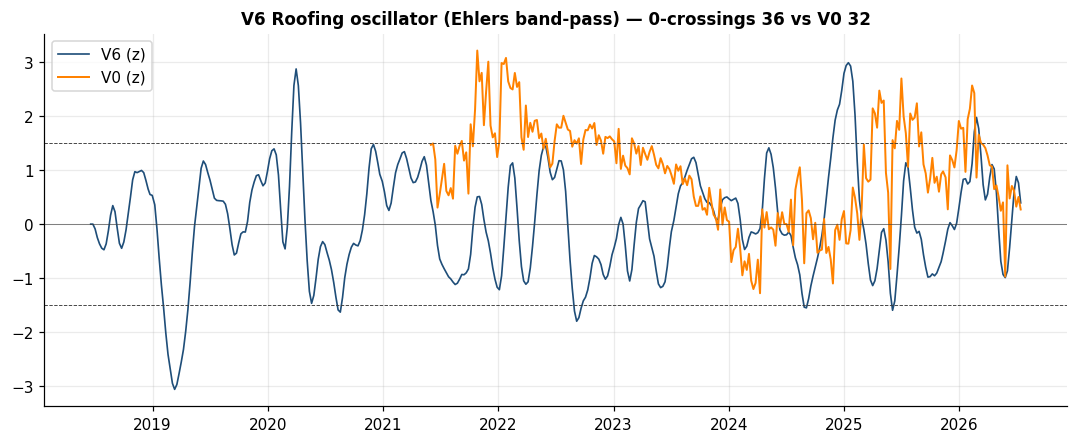

In [4]:
v0 = results["v0"].composite.dropna()
fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(c.index, richness.to_z(c, r.bounded), color=BLUE, lw=1.1, label="V6 (z)")
ax.plot(v0.index, richness.to_z(v0, False), color=ORANGE, lw=1.3, label="V0 (z)")
zline(ax); ax.legend(loc="upper left")
ax.set_title(f"{r.name[:48]} — 0-crossings {crossings(richness.to_z(c, r.bounded))} vs V0 {crossings(richness.to_z(v0, False))}")
display(fig); plt.close(fig)

## Variants

In [5]:
cfgs = [{}, {"output":"phase"}, {"output":"fisher"}, {"cell_level":True}, {"norm_mode":"fracdiff"}]
rows = []
for cfg in cfgs:
    rr = compare.BUILDERS["v6"](inp, cfg)
    cc = rr.composite.dropna()
    s = richness.score(rr.composite, inp.y10_w, bounded=rr.bounded, baseline=results["v0"].composite, name="v6")
    g = s.get("gate") or {}
    rows.append({"cfg": str(cfg)[:34], "n": len(cc), "latest": (cc.iloc[-1] if len(cc) else np.nan),
                 "0-cross": crossings(richness.to_z(cc, rr.bounded)),
                 "incr_ic": (g.get("incremental_ic")), "surr_p": g.get("surrogate_p"),
                 "cpcv_ic": g.get("cpcv_ic"), "t": g.get("t"), "pass": g.get("pass")})
show(pd.DataFrame(rows).round(3))
try:
    cf = compare.BUILDERS["v6"](inp, {}).meta
    print("CF cross-check corr(cf_cycle, oscillator):", cf.get("cf_corr"))
except Exception as e:
    print("cf:", e)

,cfg,n,latest,0-cross,incr_ic,surr_p,cpcv_ic,t,pass
0,{},422,4.544,36,-0.650,0.119,-0.129,-0.299,False
1,{'output': 'phase'},422,0.949,75,-0.352,0.380,-0.013,-0.406,False
2,{'output': 'fisher'},397,-0.067,29,-0.091,0.818,0.010,-0.525,False
3,{'cell_level': True},422,0.791,38,-0.706,0.061,-0.100,-0.232,False
4,{'norm_mode': 'fracdiff'},51,-4.545,5,NaN,NaN,NaN,-0.031,False


CF cross-check corr(cf_cycle, oscillator): 0.6826038923419281


### Note
`phase`/`fisher` outputs and `cell_level=True` (roof each cell then aggregate) and `norm_mode='fracdiff'` are all selectable. Watch the **gate** column: more crossings only 'count' if their incremental IC survives.